# AIML ZG519 – Natural Language Processing Applications
# Assignment: Sentiment Analysis – A Comparative Study

**Session Reference:** Session 6 (Sentiment Analysis) — builds on Sessions 3–5 (RAG, QA, Conversational AI)

**Group No.:** 85

**Problem Statement:** PS3

**Group Members (Name, BITS ID):**
- AVIK RAJ, 2025AE05301
- PREM KUMAR JAYWARDHAN, 2025AE05313
- HARSH GARG, 2025AE05335

---

## Objective
In this assignment you will build **four different sentiment analysis pipelines** on the same
dataset — classical Machine Learning, Deep Learning, a fine-tuned Transformer, and a
Generative AI / LLM prompting approach — and compare them on accuracy, robustness,
interpretability, latency and cost.

**Total Marks: 10**

Fill in every cell marked `# TODO`. Do not delete the markdown instructions — they are part
of your submission and will be used for evaluation. Answer the **reflection questions** at the
end of each part in the markdown cell provided.

## Learning Outcomes
- LO2: Hands-on experience with major NLP technologies and tools
- LO3: Apply NLP techniques (sentiment analysis) using state-of-the-art Gen AI techniques
- LO4: Sharpen programming skills for NLP applications

### Fill in your Group Details
Please fill in your Group Number, Problem Statement ID, Domain, Dataset used, and Aspect focus in the table above based on your assignment brief. For PS3, the Domain is 'Aviation / Travel', the Suggested Dataset is 'Twitter US Airline Sentiment (Kaggle)', and the Aspect Focus is 'delay, crew behaviour, baggage, comfort'.

## 0. Environment Setup

Run this cell first. If you are on Google Colab, uncomment the `pip install` line.


In [7]:
# !pip install -q scikit-learn nltk gensim tensorflow transformers datasets torch openai matplotlib seaborn pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, time, json, random
import kagglehub
import nltk
from nltk.corpus import stopwords
from collections import Counter
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

random.seed(42)
np.random.seed(42)

sns.set_style("whitegrid")
%matplotlib inline
print("All imports completed")

All imports completed


## 1. Dataset — Your Assigned Problem Statement

Your group has been assigned ONE problem statement (PS1–PS7) in the **Assignment Brief**,
based on your group number. Fill in the table below with your group's details before doing
anything else — the TA will cross-check this against the group allocation list.

| Field | Your Group's Value |
|---|---|
| Group Number | `<TODO>` |
| Problem Statement ID | `<TODO — e.g. PS3>` |
| Domain | `<TODO — e.g. Aviation / Travel>` |
| Dataset used | `<TODO — exact dataset name + source>` |
| Aspect focus (for Parts F & G) | `<TODO — copy from the brief's PS table>` |

| PS | Domain | Suggested Dataset | Aspect Focus |
|---|---|---|---|
| PS1 | E-Commerce Product Reviews | `amazon_polarity` (one category) or Flipkart Reviews (Kaggle) | price, delivery, quality, packaging |
| PS2 | Movie / OTT Reviews | `imdb` or Rotten Tomatoes | acting, plot, cinematography, pacing |
| PS3 | Airline & Travel | Twitter US Airline Sentiment (Kaggle) | delay, crew behaviour, baggage, comfort |
| PS4 | Restaurant / Food-Delivery | `yelp_polarity` or Zomato Reviews (Kaggle) | taste, delivery time, hygiene, packaging |
| PS5 | Healthcare: Patient Drug Reviews | UCI Drug Review Dataset (Kaggle) | effectiveness, side effects, ease of use |
| PS6 | Financial News & Market Sentiment | `financial_phrasebank` or Twitter Financial News Sentiment | earnings, macro risk, bullish/bearish tone |
| PS7 | Mobile App Store Reviews | Google Play Store App Reviews (Kaggle) or `app_reviews` (HuggingFace) | app crashes/bugs, UI/UX, feature requests, pricing |

> **Tip:** Sample 5,000–10,000 rows (stratified) if your dataset is larger, so classical ML and
> deep learning training stay fast in Colab. Keep the same sample for ALL four approaches
> (Parts B–E) so comparisons are fair. If your assigned dataset naturally has fewer rows
> (e.g. PS3, PS6), use the full dataset and note the smaller size in your report.
>
> **PS5 groups:** do not frame any output as medical advice or diagnosis — see the brief's note
> tying this to Session 7 (Privacy & Ethics in NLP).
>
> **PS7 groups:** star ratings (1–5) can be mapped to sentiment labels (e.g. 1–2 star =
> Negative, 3 = Neutral, 4–5 = Positive) if your chosen dataset doesn't ship explicit labels.


In [2]:
# Set the path to the file you'd like to load
file_path = "Tweets.csv" # Changed from "airline-tweets.csv" to "Tweets.csv"

# Load the latest version
raw = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "crowdflower/twitter-airline-sentiment",
  file_path
)

# Perform a train-test split on the raw DataFrame
# Assuming 'airline_sentiment' is the target column for stratification

X = raw.drop('airline_sentiment', axis=1)
y = raw['airline_sentiment']

# First split to create full train and test sets, stratified
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df_full = pd.concat([X_train_full, y_train_full], axis=1)
test_df_full = pd.concat([X_test_full, y_test_full], axis=1)

# Sample 5000-10000 rows from the training set, stratified by class
# If the full dataset is small, use the entire dataset. PS3 dataset has 14640 rows, so sampling is appropriate.

train_sample_size = min(10000, len(train_df_full)) # Ensure not to sample more than available
test_sample_size = min(1500, len(test_df_full)) # Keep test set smaller for faster iteration

# Use train_test_split again for stratified subsampling from the _full dataframes
# We take the 'training' part of the split as our desired sample
train_df, _ = train_test_split(train_df_full, train_size=train_sample_size, random_state=42, stratify=train_df_full['airline_sentiment'])
test_df, _ = train_test_split(test_df_full, train_size=test_sample_size, random_state=42, stratify=test_df_full['airline_sentiment'])

print(f"Original dataset shape: {raw.shape}")
print(f"Train DataFrame shape: {train_df.shape}")
print(f"Test DataFrame shape: {test_df.shape}")

# Print shape, class balance, and a few sample rows
# Display the total number of rows and columns
print(f"\nDataset Shape (raw): {raw.shape}")
print("-" * 30)

# Print class balance for the full raw dataset
print("\nClass Balance (Sentiment Distribution - Full Dataset):")
display(raw['airline_sentiment'].value_counts(normalize=True))

# Print class balance for the training and testing sets to show stratification
print("\nClass Balance (Sentiment Distribution - Training Set):")
display(train_df['airline_sentiment'].value_counts(normalize=True))

print("\nClass Balance (Sentiment Distribution - Test Set):")
display(test_df['airline_sentiment'].value_counts(normalize=True))

# Display the first 5 records of the full raw dataset to understand the feature formats
print("\nFirst 5 records (raw dataset):")
display(raw.head())

# Display data types and non-null counts to identify missing values for the raw dataset
print("\nData set Info (raw dataset):")
raw.info()

Using Colab cache for faster access to the 'twitter-airline-sentiment' dataset.
Original dataset shape: (14640, 15)
Train DataFrame shape: (10000, 15)
Test DataFrame shape: (1500, 15)

Dataset Shape (raw): (14640, 15)
------------------------------

Class Balance (Sentiment Distribution - Full Dataset):


,proportion
airline_sentiment,
negative,0.626913
neutral,0.211680
positive,0.161407



Class Balance (Sentiment Distribution - Training Set):


,proportion
airline_sentiment,
negative,0.6270
neutral,0.2116
positive,0.1614



Class Balance (Sentiment Distribution - Test Set):


,proportion
airline_sentiment,
negative,0.626667
neutral,0.212000
positive,0.161333



First 5 records (raw dataset):


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)



Data set Info (raw dataset):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 

### 1.1 Exploratory Data Analysis (EDA)

Produce at minimum:
- Class distribution plot
- Review-length distribution (word count histogram)
- Word clouds or top-N frequent tokens per class

**Reflection Q1:** Is the dataset balanced? How might class imbalance affect model choice
and evaluation metric selection later in this notebook?


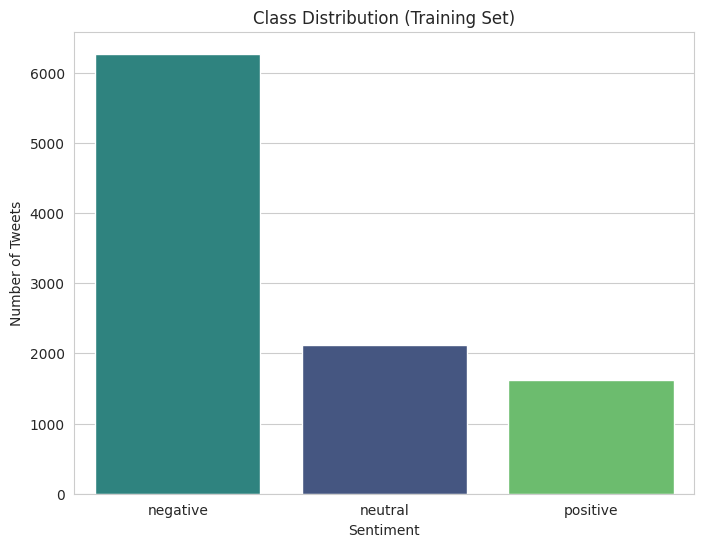

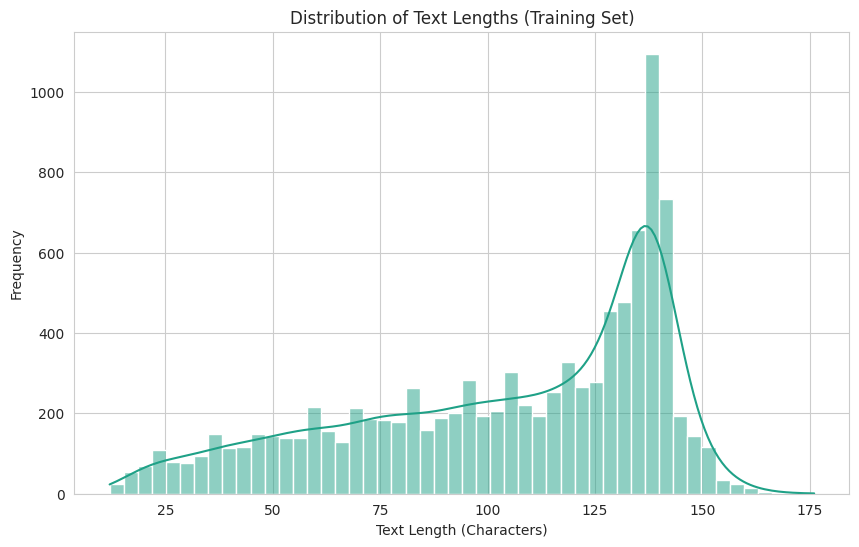


Top 10 Most Frequent Words for 'neutral' sentiment:


,Word,Count
0,flight,408
1,get,160
2,please,126
3,need,117
4,thanks,116
5,flights,113
6,help,113
7,im,98
8,would,86
9,dm,82


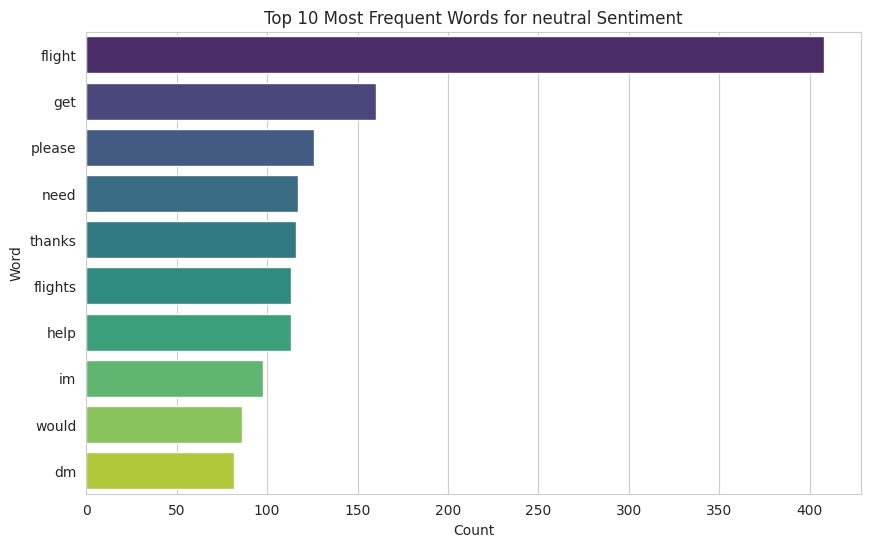


Top 10 Most Frequent Words for 'negative' sentiment:


,Word,Count
0,flight,1971
1,get,705
2,cancelled,636
3,service,471
4,hours,449
5,help,408
6,hold,404
7,time,397
8,customer,395
9,im,368


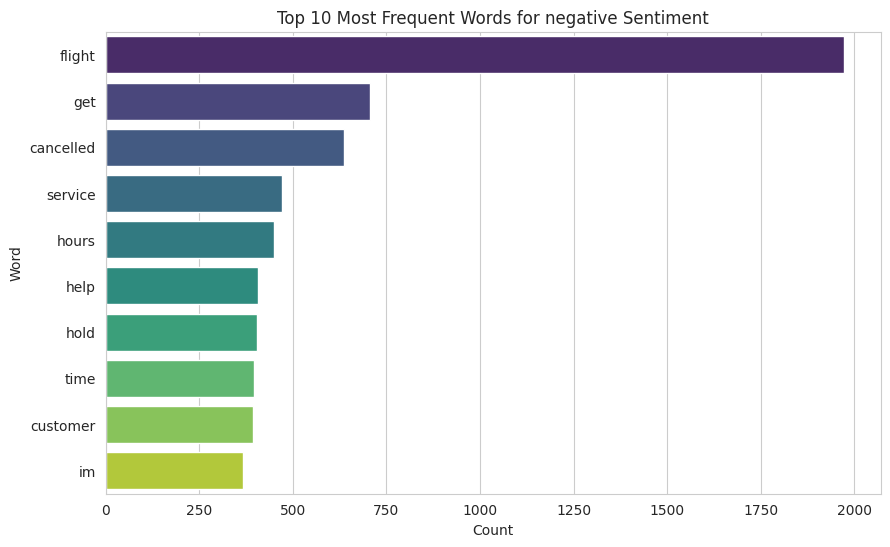


Top 10 Most Frequent Words for 'positive' sentiment:


,Word,Count
0,thanks,418
1,thank,314
2,flight,261
3,great,154
4,service,109
5,love,93
6,guys,80
7,best,78
8,get,75
9,customer,73


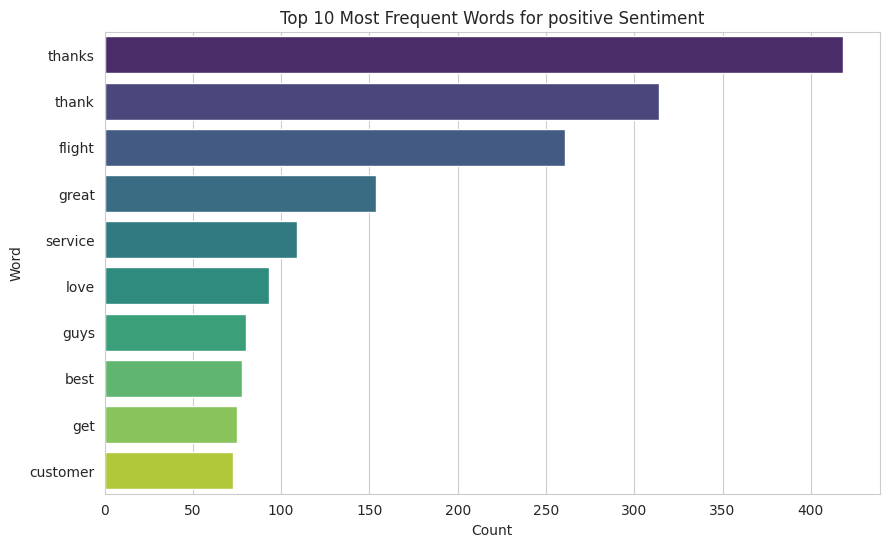

In [3]:
# EDA — class balance
# Class Distribution Plot
plt.figure(figsize=(8, 6))
sns.countplot(data=train_df, x='airline_sentiment', hue='airline_sentiment', order=train_df['airline_sentiment'].value_counts().index, palette='viridis', legend=False)
plt.title('Class Distribution (Training Set)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

# EDA — text length distribution
# Text Length Distribution
train_df['text_length'] = train_df['text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(train_df['text_length'], bins=50, kde=True, color=sns.color_palette('viridis')[3]) # Using a specific color from viridis
plt.title('Distribution of Text Lengths (Training Set)')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Frequency')
plt.show()
# Drop the temporary column after use
train_df = train_df.drop(columns=['text_length'])

# EDA — top frequent words per class (after basic cleaning)
# Top Frequent Words Per Class (after basic cleaning)

try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    print("Downloaded NLTK stopwords.")

stop_words = set(stopwords.words('english'))

def simple_clean_text_for_eda(text):
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    # Filter out non-alphabetic words and stopwords, keep words longer than 1 character
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words and len(word) > 1]
    return tokens

# Group by sentiment and find top words
sentiment_classes = train_df['airline_sentiment'].unique()

for sentiment in sentiment_classes:
    subset = train_df[train_df['airline_sentiment'] == sentiment]
    all_words = []
    for text_content in subset['text']:
        all_words.extend(simple_clean_text_for_eda(str(text_content)))

    most_common_words = Counter(all_words).most_common(10)
    print(f"\nTop 10 Most Frequent Words for '{sentiment}' sentiment:")
    words_df = pd.DataFrame(most_common_words, columns=['Word', 'Count'])
    display(words_df)

    # Plotting word frequencies for each sentiment
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y='Word', hue='Word', data=words_df, palette='viridis', legend=False) # Using viridis palette
    plt.title(f'Top 10 Most Frequent Words for {sentiment} Sentiment')
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.show()

### Top 10 Frequent Words Across All Sentiments

,Sentiment,Word,Count
0,neutral,flight,408
1,neutral,get,160
2,neutral,please,126
3,neutral,need,117
4,neutral,thanks,116
5,neutral,flights,113
6,neutral,help,113
7,neutral,im,98
8,neutral,would,86
9,neutral,dm,82


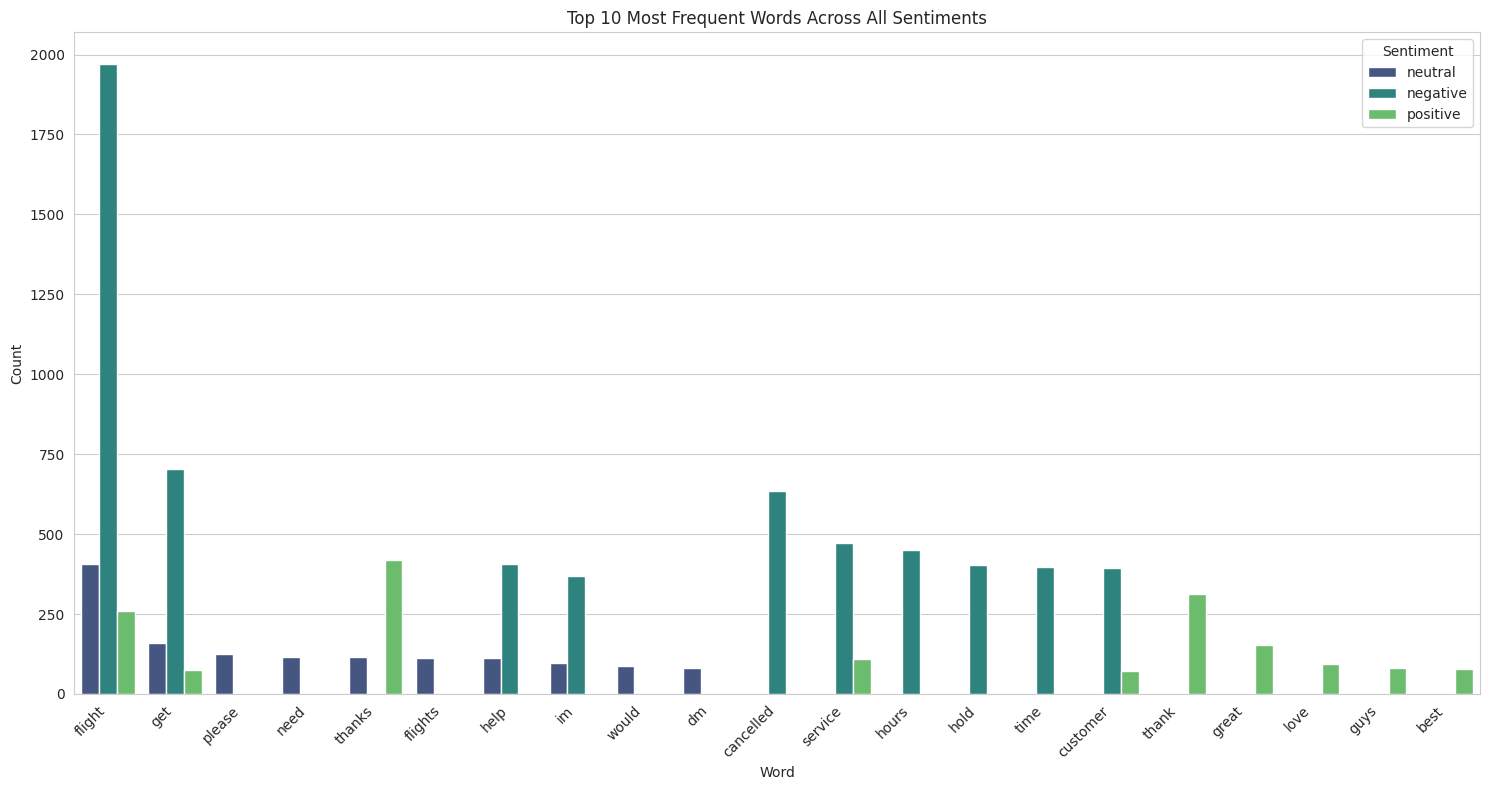

In [4]:
all_sentiments_top_words = []

for sentiment in sentiment_classes:
    subset = train_df[train_df['airline_sentiment'] == sentiment]
    all_words_for_sentiment = []
    for text_content in subset['text']:
        all_words_for_sentiment.extend(simple_clean_text_for_eda(str(text_content)))

    most_common_words = Counter(all_words_for_sentiment).most_common(10)
    for word, count in most_common_words:
        all_sentiments_top_words.append({'Sentiment': sentiment, 'Word': word, 'Count': count})

combined_words_df = pd.DataFrame(all_sentiments_top_words)
display(combined_words_df)

# Create a grouped bar chart
plt.figure(figsize=(15, 8))
sns.barplot(x='Word', y='Count', hue='Sentiment', data=combined_words_df, palette='viridis')
plt.title('Top 10 Most Frequent Words Across All Sentiments')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Reflection Q1 Answer:

**Is the dataset balanced?**

No, the dataset is highly imbalanced. As observed from the "Class Distribution (Training Set)" plot and the class balance outputs, the 'negative' sentiment class significantly dominates, followed by 'neutral', and then 'positive' as the minority class. Approximately 63% of the tweets are 'negative', while 'neutral' and 'positive' sentiments constitute around 21% and 16% respectively.

**How might class imbalance affect model choice and evaluation metric selection later in this notebook?**

Class imbalance can significantly impact model training and evaluation:

1.  **Model Bias:** Models trained on imbalanced datasets tend to be biased towards the majority class. They might achieve high overall accuracy by simply classifying most instances as the majority class, while performing poorly on the minority classes. This is especially problematic if the minority class is of critical interest (e.g., detecting rare but important events).

2.  **Model Choice:** Some models are more sensitive to class imbalance than others. Tree-based models (like Decision Trees or Random Forests) can sometimes handle imbalance better than linear models or basic neural networks without specific adjustments. Ensemble methods or models designed with cost-sensitive learning might be preferred.

3.  **Evaluation Metric Selection:** Accuracy alone is a misleading metric for imbalanced datasets. A model achieving 90% accuracy might be simply predicting the majority class for all instances if the majority class itself is 90% of the data. Therefore, other metrics are crucial:
    *   **Precision, Recall, and F1-score (especially weighted/macro-averaged):** These metrics provide a more nuanced view of performance for each class, highlighting how well the model identifies true positives among its predictions (precision) and how many true positives it captures from all actual positives (recall). The F1-score is the harmonic mean of precision and recall.
    *   **Confusion Matrix:** This visual representation clearly shows true positives, true negatives, false positives, and false negatives for each class, making it easy to identify where the model is struggling.
    *   **ROC AUC:** For binary classification, this metric is robust to class imbalance, but for multi-class, macro-averaged ROC AUC is more appropriate.

To address this, techniques like oversampling the minority class (e.g., SMOTE), undersampling the majority class, using class weights during training, or employing different evaluation metrics will be essential in later stages of this assignment.

## 2. Part A — Text Preprocessing (1 mark)

Implement a reusable `clean_text()` function. Keep two versions of the text:
- `text_classical`: heavily cleaned (lowercase, punctuation/stopword removal, lemmatization) —
  for the classical ML pipeline (Part 3).
- `text_neural`: lightly cleaned (lowercase, HTML/URL removal only) — for DL/Transformer/LLM
  pipelines (Parts 4–5), since those models learn their own representations and over-cleaning
  can hurt them.


In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_light(text: str) -> str:
    """Minimal cleaning for DL/Transformer/LLM pipelines."""
    text = re.sub(r"<.*?>", " ", text)          # strip HTML
    text = re.sub(r"http\S+", " ", text)         # strip URLs
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

def clean_text_classical(text: str) -> str:
    """Heavier cleaning for TF-IDF / BoW pipelines."""
    text = clean_text_light(text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [lemmatizer.lemmatize(t) for t in text.split() if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

# Apply both functions to train_df / test_df and store as new columns
train_df['text_classical'] = train_df['text'].apply(clean_text_classical)
train_df['text_neural']    = train_df['text'].apply(clean_text_light)
test_df['text_classical'] = test_df['text'].apply(clean_text_classical)
test_df['text_neural']    = test_df['text'].apply(clean_text_light)

print("Cleaned text columns 'text_classical' and 'text_neural' added to train_df and test_df.")


Cleaned text columns 'text_classical' and 'text_neural' added to train_df and test_df.


## 3. Part B — Classical Machine Learning (2 marks)

Build **two** classical pipelines using `TfidfVectorizer` (or `CountVectorizer`) with:
1. **Naive Bayes** (`MultinomialNB`)
2. **One of:** Logistic Regression / Linear SVM

For each: report Accuracy, Precision, Recall, F1 (weighted), and a confusion matrix.
Tune at least one hyperparameter (e.g. `ngram_range`, `max_features`, `C`) using
`GridSearchCV` or `RandomizedSearchCV` and report the best configuration.


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 1. Vectorize text_classical
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf_vectorizer.fit_transform(train_df['text_classical'])
X_test_vec = tfidf_vectorizer.transform(test_df['text_classical'])
y_train = train_df['airline_sentiment']
y_test = test_df['airline_sentiment']

# 2. Train MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
y_pred_nb = nb_model.predict(X_test_vec)

print("--- Naive Bayes Results ---")
print(classification_report(y_test, y_pred_nb))

# 3. Train LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)
y_pred_lr = lr_model.predict(X_test_vec)

print("--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred_lr))

# 4. Hyperparameter tuning with GridSearchCV on Naive Bayes
param_grid = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]}
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_vec, y_train)

print(f"Best NB Params: {grid_search.best_params_}")
print(f"Best NB Weighted F1 Score: {grid_search.best_score_:.4f}")

--- Naive Bayes Results ---
              precision    recall  f1-score   support

    negative       0.70      0.99      0.82       940
     neutral       0.72      0.18      0.29       318
    positive       0.87      0.29      0.44       242

    accuracy                           0.71      1500
   macro avg       0.76      0.49      0.52      1500
weighted avg       0.73      0.71      0.65      1500

--- Logistic Regression Results ---
              precision    recall  f1-score   support

    negative       0.81      0.93      0.86       940
     neutral       0.63      0.50      0.56       318
    positive       0.76      0.52      0.61       242

    accuracy                           0.77      1500
   macro avg       0.73      0.65      0.68      1500
weighted avg       0.76      0.77      0.76      1500

Best NB Params: {'alpha': 0.1}
Best NB Weighted F1 Score: 0.7226


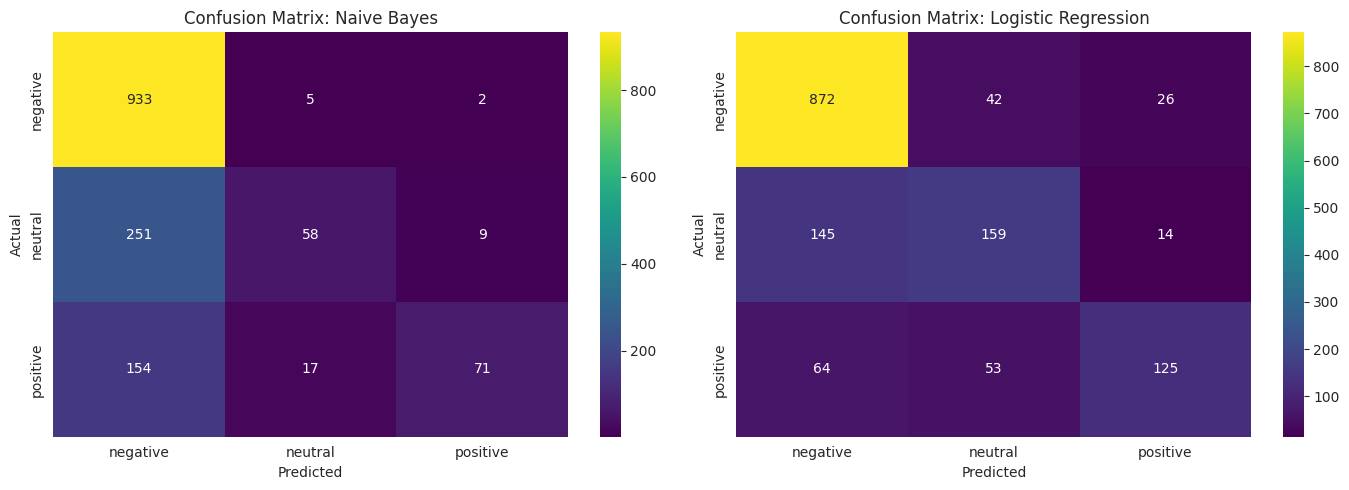

In [10]:
# Plot confusion matrices for both classical models side-by-side (use plt.subplots)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='viridis', ax=axes[0],
            xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
axes[0].set_title('Confusion Matrix: Naive Bayes')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='viridis', ax=axes[1],
            xticklabels=lr_model.classes_, yticklabels=lr_model.classes_)
axes[1].set_title('Confusion Matrix: Logistic Regression')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

**Reflection Q2:** Which classical model performed better and why do you think that is,
given the nature of TF-IDF features? What are the main limitations of a bag-of-words
representation for sentiment analysis (e.g. negation handling, word order, sarcasm)?

_Your answer:_ `TODO`


## 4. Part C — Deep Learning (2 marks)

Build a neural sentiment classifier using an embedding layer + a recurrent or convolutional
architecture (choose ONE): `BiLSTM`, `LSTM`, `GRU`, or `1D-CNN` over word embeddings (Keras/
TensorFlow or PyTorch). Use **pre-trained embeddings** (e.g. GloVe) if possible, otherwise
train an embedding layer from scratch and note the trade-off.

Report: training/validation loss & accuracy curves, test accuracy, precision, recall, F1,
and confusion matrix. Compare training time and number of parameters against the classical
model.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D, Conv1D

MAX_VOCAB = 20000
MAX_LEN = 200

# TODO: Tokenize text_neural, pad sequences to MAX_LEN

# TODO: Build a Sequential model: Embedding -> Bidirectional(LSTM) -> Dense -> Dense(sigmoid/softmax)

# TODO: Compile (optimizer='adam', loss=..., metrics=['accuracy']) and model.summary()

# TODO: Train with EarlyStopping callback, keep the History object for plotting


In [ ]:
# TODO: Plot training vs validation accuracy/loss curves (2 subplots)

# TODO: Evaluate on test set -> accuracy, F1, confusion matrix

# TODO: Print total trainable parameters and total training time (use time.time())


**Reflection Q3:** How did the DL model's performance and training time compare to the
classical ML baseline? Did pre-trained embeddings help? What would you try next to improve
this model (e.g. attention, more data, transfer learning)?

_Your answer:_ `TODO`


## 5. Part D — Transformer Fine-Tuning (2 marks)

Fine-tune a pre-trained transformer (`distilbert-base-uncased` recommended for speed, or
`bert-base-uncased`) on your sentiment dataset using the HuggingFace `transformers` +
`datasets` libraries (`Trainer` API, or a manual PyTorch training loop).

If compute is limited, fine-tune on a **smaller subset** (e.g. 2,000 train / 500 test) and
state this clearly — the comparison is still valid as long as it is fair (i.e. compare all
approaches on the same subset where possible, or clearly annotate the sample-size difference).


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

MODEL_NAME = "distilbert-base-uncased"

# TODO: Load tokenizer and model (num_labels = number of classes in your dataset)

# TODO: Tokenize train/test sets (truncation=True, padding=True, max_length=256)

# TODO: Wrap into a torch Dataset / HF Dataset object

# TODO: Define TrainingArguments (small num_train_epochs=2-3 for time budget) and Trainer

# TODO: trainer.train()


In [ ]:
# TODO: trainer.evaluate() -> accuracy, F1, precision, recall

# TODO: Confusion matrix on test predictions

# TODO: Record fine-tuning time and inference latency per 100 samples (time.time())


**Reflection Q4:** How does the fine-tuned transformer compare to the DL model from
Part B on accuracy vs. training time vs. compute cost? In what production scenario would
you NOT choose a transformer despite better accuracy?

_Your answer:_ `TODO`


## 6. Part E — Generative AI / LLM Prompting Approach (1.5 marks)

Instead of training a model, use an **LLM via prompting** to perform sentiment classification.
Implement and compare:
1. **Zero-shot prompting** — ask the LLM to classify sentiment with no examples.
2. **Few-shot prompting** — include 3–5 labelled examples in the prompt.

You may use the OpenAI API, Anthropic API, or any open-source LLM you can run locally
(e.g. via `transformers` `pipeline("sentiment-analysis")` is NOT sufficient here — that is a
fine-tuned classifier, not prompting). Evaluate on a **sample** of your test set (e.g. 100–200
rows) to control API cost.


In [ ]:
# --- Example scaffold using the OpenAI-compatible chat completion style. ---
# --- Replace with your provider of choice (OpenAI / Anthropic / local LLM). ---
# import openai
# openai.api_key = "YOUR_API_KEY"

def zero_shot_prompt(review_text: str) -> str:
    return f"""Classify the sentiment of the following review as exactly one word:
Positive, Negative, or Neutral.

Review: \"{review_text}\"

Sentiment:"""

def few_shot_prompt(review_text: str, examples: list) -> str:
    # TODO: build a prompt that prepends 3-5 (review, label) example pairs, then asks
    # for the label of `review_text`
    pass

def call_llm(prompt: str) -> str:
    # TODO: call your chosen LLM API/model and return the raw text response
    # response = openai.chat.completions.create(model="gpt-4o-mini",
    #                messages=[{"role": "user", "content": prompt}], temperature=0)
    # return response.choices[0].message.content.strip()
    raise NotImplementedError

# TODO: sample ~150 rows from test_df
# TODO: run zero_shot_prompt over the sample, parse predicted label, measure latency + (est.) cost
# TODO: run few_shot_prompt over the same sample
# TODO: compute accuracy / F1 for each prompting strategy, compare to Parts 3-5


**Reflection Q5:** Did few-shot prompting improve over zero-shot? How did LLM prompting
accuracy compare to the fine-tuned transformer — and how do the *costs* compare (API cost
per 1,000 predictions vs. one-time fine-tuning + free inference)? When would you prefer
prompting over fine-tuning in a real product?

_Your answer:_ `TODO`


## 7. Part F — Comparative Analysis & Report (1.5 marks)

Consolidate results from Parts 3–6 into a single comparison table and at least one chart.
Discuss trade-offs beyond raw accuracy: **training/setup time, inference latency, cost,
data requirements, interpretability, and robustness** (e.g. test each model on 5 tricky
examples you write yourself — negation, sarcasm, mixed sentiment — and report how each
approach handles them).


In [ ]:
results = pd.DataFrame({
    "Approach": ["Naive Bayes", "LogReg/SVM", "BiLSTM/CNN", "Fine-tuned Transformer",
                 "LLM Zero-shot", "LLM Few-shot"],
    "Accuracy": [None]*6,     # TODO fill from your runs above
    "F1 (weighted)": [None]*6,
    "Train/Setup Time (s)": [None]*6,
    "Inference Latency (ms/sample)": [None]*6,
    "Approx. Cost": ["Free", "Free", "Free (compute)", "Free (compute, one-time)",
                      "$ per call", "$ per call (higher, longer prompt)"],
})
results


In [ ]:
# TODO: Bar chart comparing Accuracy and F1 across all approaches
# TODO: (Optional) Bar/line chart comparing latency across approaches (log scale often helps)


> Write your own 5 stress-test examples **in your assigned domain** (see the Aspect Focus
> column for your PS in the brief), covering: negation, sarcasm, mixed sentiment, a
> neutral/ambiguous case, and a double negation. The placeholders below are illustrative only
> — replace them with domain-appropriate sentences before running.


In [ ]:
# --- Robustness stress-test: REPLACE with 5 examples from YOUR assigned domain ---
tricky_examples = [
    "TODO: negation example in your domain",
    "TODO: sarcasm example in your domain",
    "TODO: mixed-sentiment example in your domain",
    "TODO: neutral/ambiguous example in your domain",
    "TODO: double-negation example in your domain",
]

# TODO: run each of your trained/prompted approaches on `tricky_examples` and tabulate
# predictions side-by-side to compare qualitatively


### Final Written Summary (Required)

Write a 250–400 word summary covering:
1. Which approach would you deploy in production for a **high-traffic, cost-sensitive**
   consumer app (e.g. e-commerce review moderation), and why?
2. Which approach would you deploy for a **low-volume, high-stakes** use case (e.g.
   analyzing patient feedback in healthcare), and why?
3. One ethical/privacy consideration relevant to sending user-generated text (reviews,
   messages) to a third-party LLM API, referencing the course's Session 7 (Privacy & Ethics
   in NLP).

_Your summary:_ `TODO`


## Submission Checklist

- [ ] All `# TODO` code cells completed and executed top-to-bottom without errors
- [ ] All 5 reflection questions answered
- [ ] Comparison table (Part F) fully populated with real numbers
- [ ] Final written summary completed
- [ ] Notebook renamed to `<PSid>_Group<GroupNo>_NLP_SentimentAnalysis_Assignment.ipynb` (e.g. `PS3_Group12_NLP_SentimentAnalysis_Assignment.ipynb`)
- [ ] Group number, problem statement, and all group members' names/IDs filled in at the top
- [ ] (If using paid LLM APIs) API keys removed before submission — do NOT commit secrets

**Academic Integrity:** You may use AI coding assistants to help write boilerplate code, but
the analysis, reflections, and final summary must be your own original interpretation of
your results.
